# DIGITAL MODULATIONS CLASSIFIER


## INTRODUCCIÓN


#### En los sistemas de comunicación digital, las señales transmitidas utilizan diferentes tipos de modulación, como BPSK, QPSK, 8PSK, 16-QAM y 64-QAM, para representar información en forma de bits. El problema surge cuando una señal es recibida y no se conoce previamente qué tipo de modulación fue utilizada. Esta situación es común en escenarios de monitoreo del espectro radioeléctrico, análisis de señales inalámbricas, radio definida por software, comunicaciones cognitivas e identificación de interferencias. Por ello, clasificar automáticamente el tipo de modulación se convierte en una tarea importante para interpretar correctamente una señal y facilitar procesos posteriores como su análisis, demodulación o gestión.

#### El problema a resolver en este proyecto consiste en desarrollar un modelo de machine learning capaz de identificar automáticamente la modulación digital de una señal a partir de sus componentes IQ, es decir, la información en fase y cuadratura que describe el comportamiento de la señal. Esta tarea no es sencilla, porque las modulaciones pueden presentar patrones similares entre sí, especialmente cuando existe ruido en el canal o cuando se trabaja con modulaciones más complejas como 16-QAM y 64-QAM. Además, el desempeño del clasificador puede variar según el nivel de SNR, lo que hace necesario evaluar si el modelo logra aprender diferencias reales entre las clases.

#### La importancia de este problema radica en que la clasificación automática de modulaciones permite reducir la dependencia de métodos manuales o basados exclusivamente en reglas diseñadas por expertos. En lugar de extraer características de forma tradicional, una red neuronal puede aprender patrones directamente desde los datos. En este proyecto se utilizará una red neuronal tipo MLP sobre el dataset RML2016.10A, seleccionando las modulaciones BPSK, QPSK, 8PSK, 16-QAM y 64-QAM. Con esto, se busca aplicar una metodología completa de aprendizaje automático para construir, optimizar y evaluar un modelo capaz de clasificar señales digitales, analizando además cómo el ruido afecta su rendimiento.

## EDA

### Cargar el archivo

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

path = "../../data/RML2016.10a_dict.pkl"

with open(path, "rb") as f:
    data = pickle.load(f, encoding="latin1")

### Claves del diccionario

In [2]:
keys = list(data.keys())

print("Número de combinaciones modulación-SNR:", len(keys))
print("Primeras claves:")
print(keys[:20])

Número de combinaciones modulación-SNR: 220
Primeras claves:
[('QPSK', 2), ('PAM4', 8), ('AM-DSB', -4), ('GFSK', 6), ('QAM64', 8), ('AM-SSB', 12), ('8PSK', 8), ('8PSK', 12), ('QAM64', -6), ('QAM16', 2), ('QAM16', -20), ('PAM4', -6), ('WBFM', -18), ('AM-DSB', 16), ('CPFSK', 10), ('WBFM', 6), ('BPSK', 4), ('BPSK', -2), ('QPSK', -20), ('CPFSK', -8)]


In [3]:
# Se separa modulaciones y SNR disponibles
mods = sorted(list(set([k[0] for k in keys])))
snrs = sorted(list(set([k[1] for k in keys])))

print("Modulaciones disponibles:", mods)
print("SNR disponibles:", snrs)

Modulaciones disponibles: ['8PSK', 'AM-DSB', 'AM-SSB', 'BPSK', 'CPFSK', 'GFSK', 'PAM4', 'QAM16', 'QAM64', 'QPSK', 'WBFM']
SNR disponibles: [-20, -18, -16, -14, -12, -10, -8, -6, -4, -2, 0, 2, 4, 6, 8, 10, 12, 14, 16, 18]


In [4]:
selected_mods = ['BPSK', 'QPSK', '8PSK', 'QAM16', 'QAM64']

### Forma de los datos IQ

In [5]:
example_key = keys[0]
example_data = data[example_key]

print("Clave ejemplo:", example_key)
print("Forma del arreglo:", example_data.shape)

Clave ejemplo: ('QPSK', 2)
Forma del arreglo: (1000, 2, 128)


###### El dataset está organizado como un diccionario donde cada clave corresponde a una combinación entre modulación y SNR. Cada clave tiene la forma (modulación, SNR), por ejemplo ('QPSK', 18). El valor asociado a cada clave es un arreglo con forma (1000, 2, 128), donde 1000 representa el número de señales, 2 corresponde a los canales I y Q, y 128 representa las muestras temporales de cada señal.

### DataFrame resumen del dataset

In [6]:
summary = []

for (mod, snr), samples in data.items():
    summary.append({
        "modulation": mod,
        "snr": snr,
        "num_samples": samples.shape[0],
        "channels": samples.shape[1],
        "signal_length": samples.shape[2]
    })

df_summary = pd.DataFrame(summary)
df_summary.head()

,modulation,snr,num_samples,channels,signal_length
0,QPSK,2,1000,2,128
1,PAM4,8,1000,2,128
2,AM-DSB,-4,1000,2,128
3,GFSK,6,1000,2,128
4,QAM64,8,1000,2,128


In [7]:
# modulaciones a usar
selected_mods = ['BPSK', 'QPSK', '8PSK', 'QAM16', 'QAM64']

df_selected = df_summary[df_summary["modulation"].isin(selected_mods)]

df_selected.head()


,modulation,snr,num_samples,channels,signal_length
0,QPSK,2,1000,2,128
4,QAM64,8,1000,2,128
6,8PSK,8,1000,2,128
7,8PSK,12,1000,2,128
8,QAM64,-6,1000,2,128


### Balance por clase

In [8]:
class_counts = df_selected.groupby("modulation")["num_samples"].sum()
print(class_counts)

modulation
8PSK     20000
BPSK     20000
QAM16    20000
QAM64    20000
QPSK     20000
Name: num_samples, dtype: int64


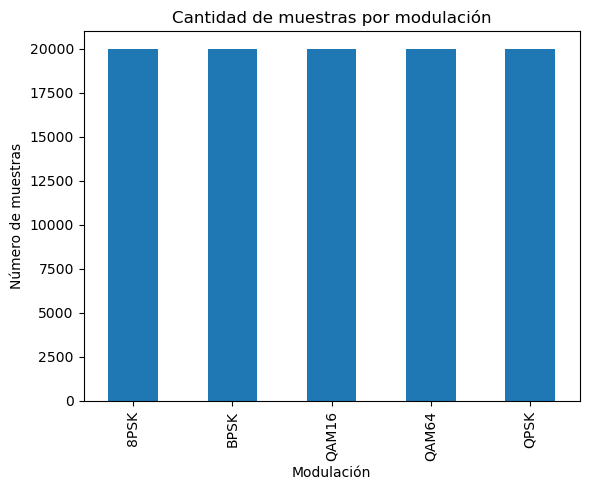

In [9]:
class_counts.plot(kind="bar")
plt.title("Cantidad de muestras por modulación")
plt.xlabel("Modulación")
plt.ylabel("Número de muestras")
plt.show()

### Distribución por SNR

In [10]:
snr_counts = df_selected.groupby("snr")["num_samples"].sum()
print(snr_counts)

snr
-20    5000
-18    5000
-16    5000
-14    5000
-12    5000
-10    5000
-8     5000
-6     5000
-4     5000
-2     5000
 0     5000
 2     5000
 4     5000
 6     5000
 8     5000
 10    5000
 12    5000
 14    5000
 16    5000
 18    5000
Name: num_samples, dtype: int64


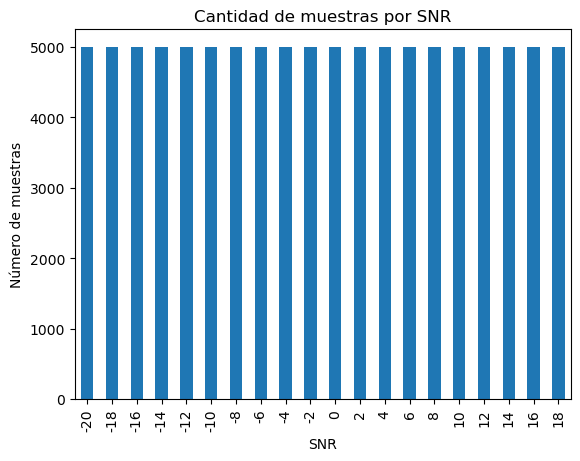

In [11]:
snr_counts.plot(kind="bar")
plt.title("Cantidad de muestras por SNR")
plt.xlabel("SNR")
plt.ylabel("Número de muestras")
plt.show()

### Distribución cruzada modulación-SNR

In [12]:
pivot = df_selected.pivot_table(
    values="num_samples",
    index="modulation",
    columns="snr",
    aggfunc="sum"
)

pivot

snr,-20,-18,-16,-14,-12,-10,-8,-6,-4,-2,0,2,4,6,8,10,12,14,16,18
modulation,,,,,,,,,,,,,,,,,,,,
8PSK,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
BPSK,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
QAM16,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
QAM64,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000
QPSK,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000,1000


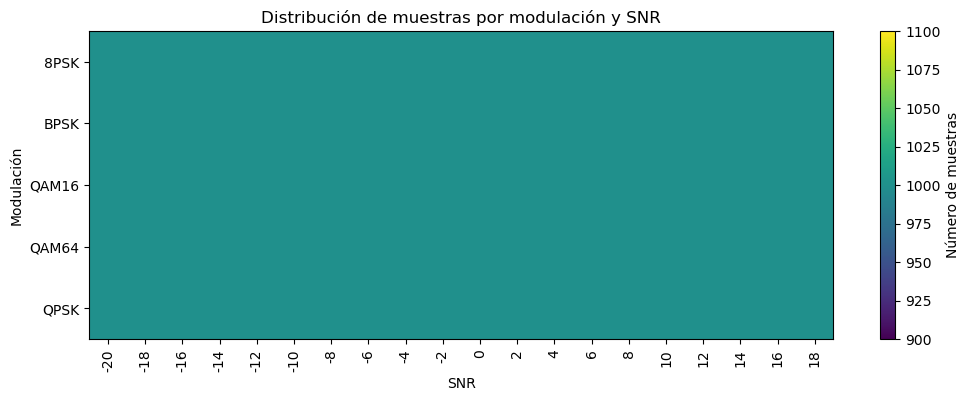

In [13]:
plt.figure(figsize=(12, 4))
plt.imshow(pivot, aspect="auto")
plt.colorbar(label="Número de muestras")
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=90)
plt.yticks(range(len(pivot.index)), pivot.index)
plt.title("Distribución de muestras por modulación y SNR")
plt.xlabel("SNR")
plt.ylabel("Modulación")
plt.show()

### Construir dataset final X, y, SNR

In [14]:
X = []
y = []
snr_values = []

for (mod, snr), samples in data.items():
    if mod in selected_mods:
        X.append(samples)
        y.extend([mod] * samples.shape[0])
        snr_values.extend([snr] * samples.shape[0])

X = np.vstack(X)
y = np.array(y)
snr_values = np.array(snr_values)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("snr shape:", snr_values.shape)

X shape: (100000, 2, 128)
y shape: (100000,)
snr shape: (100000,)


In [15]:
X_flat = X.reshape(X.shape[0], -1)

print("X para MLP:", X_flat.shape)

X para MLP: (100000, 256)


### Faltantes, infinitos o anómalos

In [16]:
print("NaN:", np.isnan(X).sum())
print("Inf:", np.isinf(X).sum())

print("Valor mínimo:", X.min())
print("Valor máximo:", X.max())
print("Media:", X.mean())
print("Desviación estándar:", X.std())


NaN: 0
Inf: 0
Valor mínimo: -0.15494554
Valor máximo: 0.16422912
Media: -4.7892547e-05
Desviación estándar: 0.0060583474


### Señales IQ en el tiempo

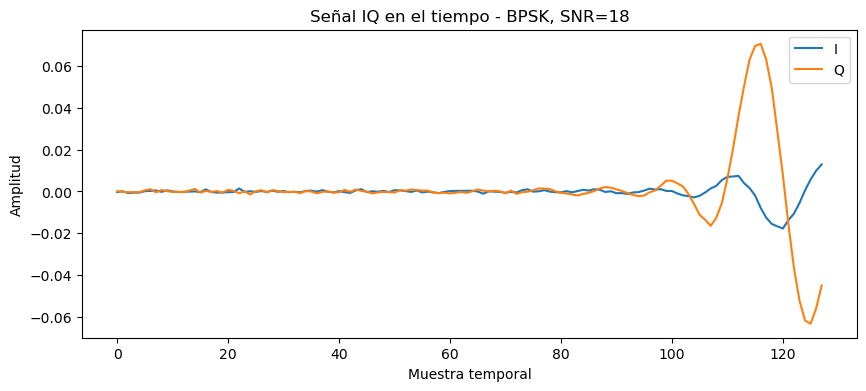

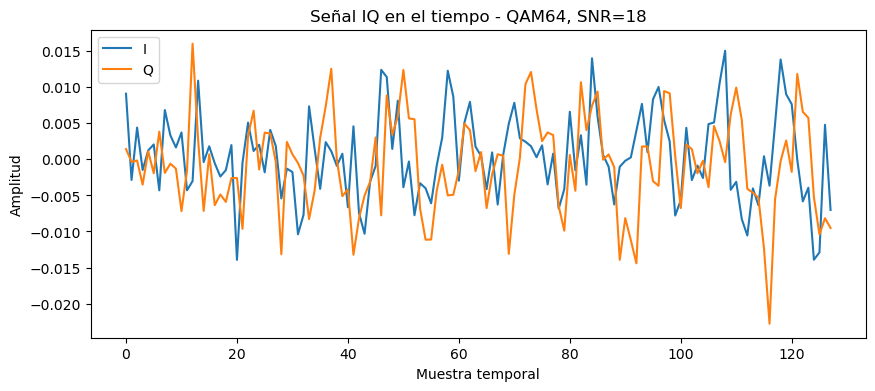

In [17]:
def plot_iq_signal(X, y, snr_values, modulation, snr, index=0):
    idx = np.where((y == modulation) & (snr_values == snr))[0]
    sample = X[idx[index]]
    
    I = sample[0]
    Q = sample[1]
    
    plt.figure(figsize=(10, 4))
    plt.plot(I, label="I")
    plt.plot(Q, label="Q")
    plt.title(f"Señal IQ en el tiempo - {modulation}, SNR={snr}")
    plt.xlabel("Muestra temporal")
    plt.ylabel("Amplitud")
    plt.legend()
    plt.show()

plot_iq_signal(X, y, snr_values, "BPSK", 18)
plot_iq_signal(X, y, snr_values, "QAM64", 18)

### Constelaciones

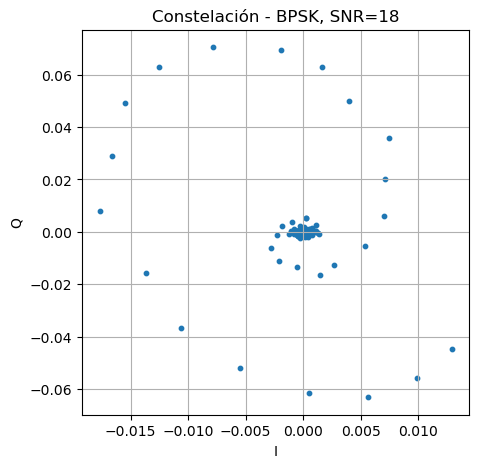

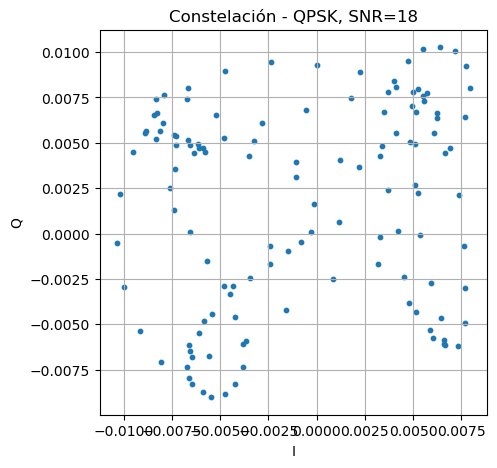

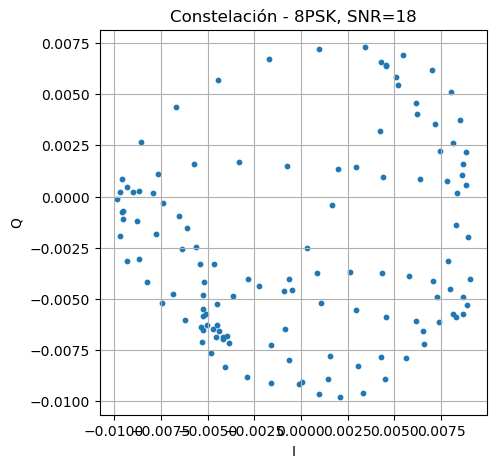

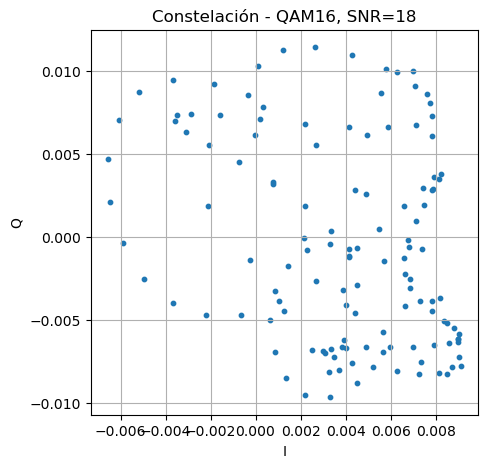

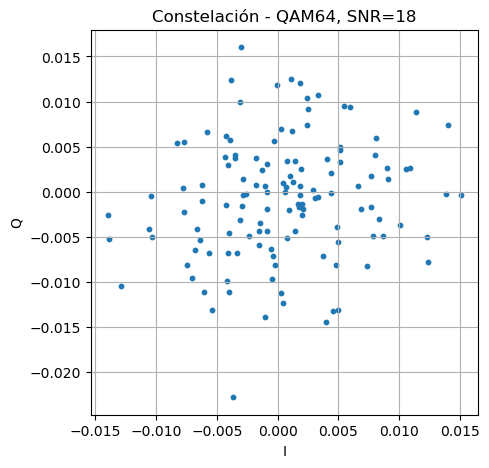

In [18]:
def plot_constellation(X, y, snr_values, modulation, snr, index=0):
    idx = np.where((y == modulation) & (snr_values == snr))[0]
    sample = X[idx[index]]
    
    I = sample[0]
    Q = sample[1]
    
    plt.figure(figsize=(5, 5))
    plt.scatter(I, Q, s=10)
    plt.title(f"Constelación - {modulation}, SNR={snr}")
    plt.xlabel("I")
    plt.ylabel("Q")
    plt.grid(True)
    plt.show()

for mod in selected_mods:
    plot_constellation(X, y, snr_values, mod, 18)


In [19]:
def compare_constellation_snr(X, y, snr_values, modulation, snr_high=18, snr_low=-10, index=0):
    # Índices para SNR alto
    idx_high = np.where((y == modulation) & (snr_values == snr_high))[0]
    sample_high = X[idx_high[index]]
    
    I_high = sample_high[0]
    Q_high = sample_high[1]
    
    # Índices para SNR bajo
    idx_low = np.where((y == modulation) & (snr_values == snr_low))[0]
    sample_low = X[idx_low[index]]
    
    I_low = sample_low[0]
    Q_low = sample_low[1]
    
    # Gráficas comparativas
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    
    axes[0].scatter(I_high, Q_high, s=10)
    axes[0].set_title(f"{modulation}, SNR={snr_high}")
    axes[0].set_xlabel("I")
    axes[0].set_ylabel("Q")
    axes[0].grid(True)
    axes[0].axis("equal")
    
    axes[1].scatter(I_low, Q_low, s=10)
    axes[1].set_title(f"{modulation}, SNR={snr_low}")
    axes[1].set_xlabel("I")
    axes[1].set_ylabel("Q")
    axes[1].grid(True)
    axes[1].axis("equal")
    
    plt.suptitle(f"Comparación de constelaciones para {modulation}")
    plt.show()

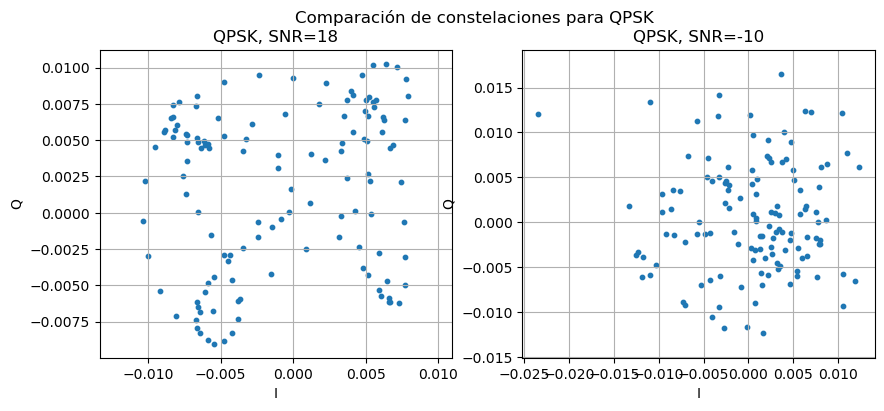

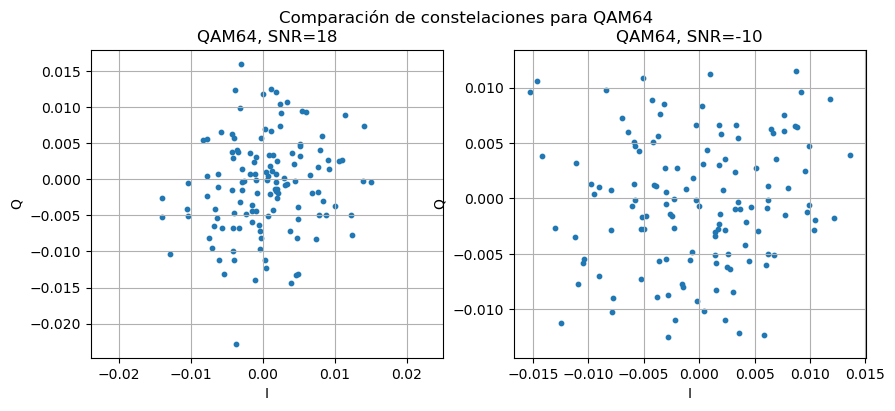

In [20]:
compare_constellation_snr(X, y, snr_values, "QPSK", 18, -10)
compare_constellation_snr(X, y, snr_values, "QAM64", 18, -10)

### Analizar amplitud y fase

In [21]:
I = X[:, 0, :]
Q = X[:, 1, :]

amplitude = np.sqrt(I**2 + Q**2)
phase = np.arctan2(Q, I)

print("Amplitude shape:", amplitude.shape)
print("Phase shape:", phase.shape)

Amplitude shape: (100000, 128)
Phase shape: (100000, 128)


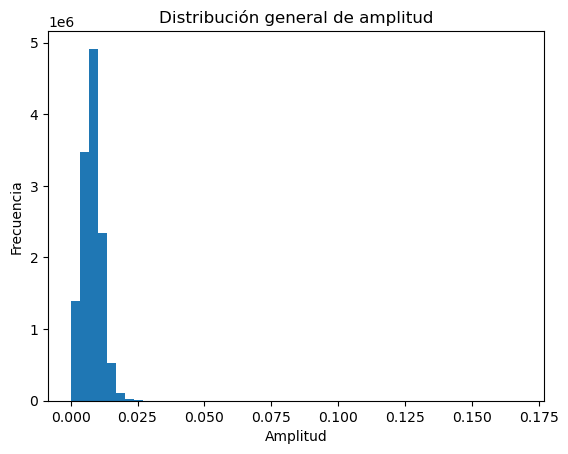

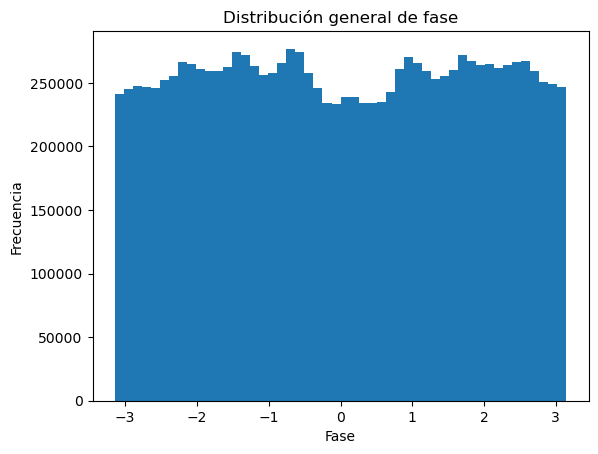

In [22]:
plt.hist(amplitude.flatten(), bins=50)
plt.title("Distribución general de amplitud")
plt.xlabel("Amplitud")
plt.ylabel("Frecuencia")
plt.show()

plt.hist(phase.flatten(), bins=50)
plt.title("Distribución general de fase")
plt.xlabel("Fase")
plt.ylabel("Frecuencia")
plt.show()

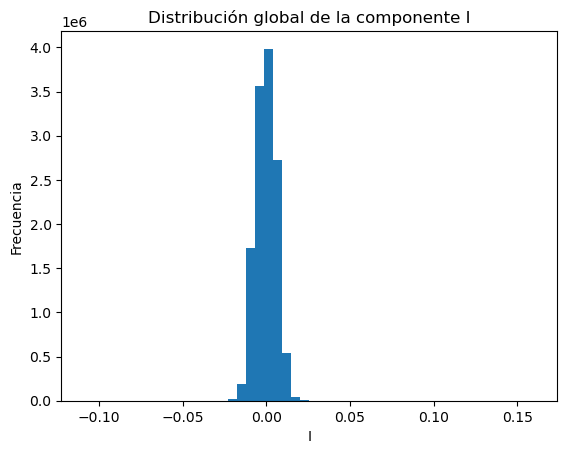

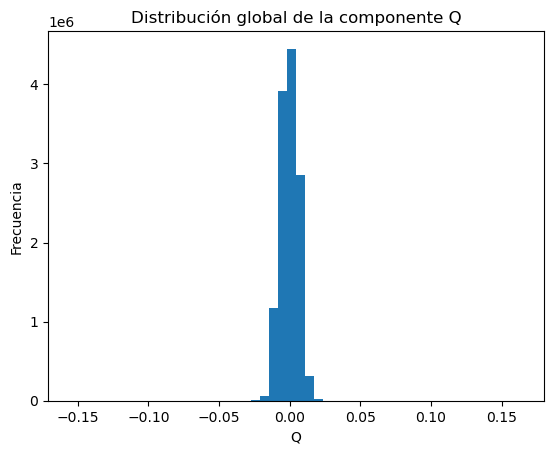

In [23]:
# Distribución global de I y Q
I = X[:, 0, :]
Q = X[:, 1, :]

plt.hist(I.flatten(), bins=50)
plt.title("Distribución global de la componente I")
plt.xlabel("I")
plt.ylabel("Frecuencia")
plt.show()

plt.hist(Q.flatten(), bins=50)
plt.title("Distribución global de la componente Q")
plt.xlabel("Q")
plt.ylabel("Frecuencia")
plt.show()

### Potencia promedio por modulación

In [24]:
power = np.mean(I**2 + Q**2, axis=1)

df_features = pd.DataFrame({
    "modulation": y,
    "snr": snr_values,
    "power": power
})

df_features.groupby("modulation")["power"].describe()

,count,mean,std,min,25%,50%,75%,max
modulation,,,,,,,,
8PSK,20000.0,0.000072,0.000009,0.000062,0.000066,0.000073,0.000078,0.000491
BPSK,20000.0,0.000074,0.000007,0.000063,0.000070,0.000074,0.000078,0.000533
QAM16,20000.0,0.000074,0.000009,0.000064,0.000070,0.000073,0.000077,0.000647
QAM64,20000.0,0.000074,0.000011,0.000064,0.000071,0.000073,0.000076,0.000519
QPSK,20000.0,0.000072,0.000009,0.000062,0.000066,0.000073,0.000078,0.000477


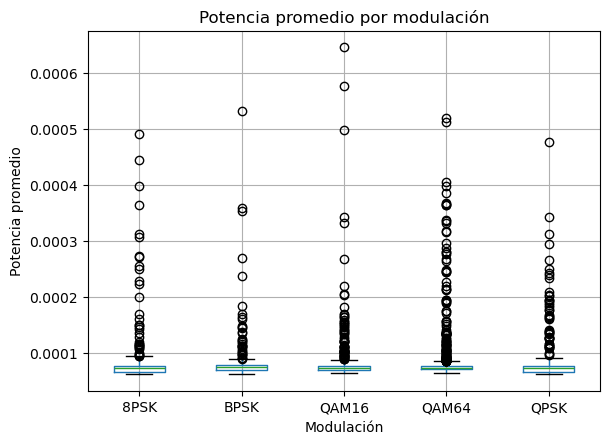

In [25]:
df_features.boxplot(column="power", by="modulation")
plt.title("Potencia promedio por modulación")
plt.suptitle("")
plt.xlabel("Modulación")
plt.ylabel("Potencia promedio")
plt.show()

### EDA de características derivadas de la señal IQ

In [26]:
# Características derivadas para análisis exploratorio

I = X[:, 0, :]
Q = X[:, 1, :]

amplitude = np.sqrt(I**2 + Q**2)
phase = np.arctan2(Q, I)
power_inst = I**2 + Q**2

phase_sin = np.sin(phase)
phase_cos = np.cos(phase)

df_eda_features = pd.DataFrame({
    "modulation": y,
    "snr": snr_values,
    "amplitude_mean": amplitude.mean(axis=1),
    "amplitude_std": amplitude.std(axis=1),
    "power_mean": power_inst.mean(axis=1),
    "power_std": power_inst.std(axis=1),
    "phase_sin_mean": phase_sin.mean(axis=1),
    "phase_cos_mean": phase_cos.mean(axis=1)
})

df_eda_features.head()

,modulation,snr,amplitude_mean,amplitude_std,power_mean,power_std,phase_sin_mean,phase_cos_mean
0,QPSK,2,0.007812,0.002740,0.000069,0.000042,0.076101,-0.023114
1,QPSK,2,0.007812,0.002668,0.000068,0.000043,0.059835,0.089493
2,QPSK,2,0.007812,0.002873,0.000069,0.000047,0.056260,0.070240
3,QPSK,2,0.007812,0.002991,0.000070,0.000049,0.031913,0.035141
4,QPSK,2,0.007813,0.002578,0.000068,0.000041,-0.157287,0.172426


In [27]:
df_eda_features.groupby("modulation")[
    ["amplitude_mean", "amplitude_std", "power_mean", "power_std", "phase_sin_mean", "phase_cos_mean"]
].mean()

,amplitude_mean,amplitude_std,power_mean,power_std,phase_sin_mean,phase_cos_mean
modulation,,,,,,
8PSK,0.007812,0.003220,0.000072,0.000057,-0.003972,-0.006388
BPSK,0.007812,0.003577,0.000074,0.000062,-0.002561,-0.006067
QAM16,0.007812,0.003515,0.000074,0.000061,-0.003757,-0.004369
QAM64,0.007812,0.003523,0.000074,0.000062,-0.000347,-0.004483
QPSK,0.007812,0.003221,0.000072,0.000057,-0.001751,-0.005619


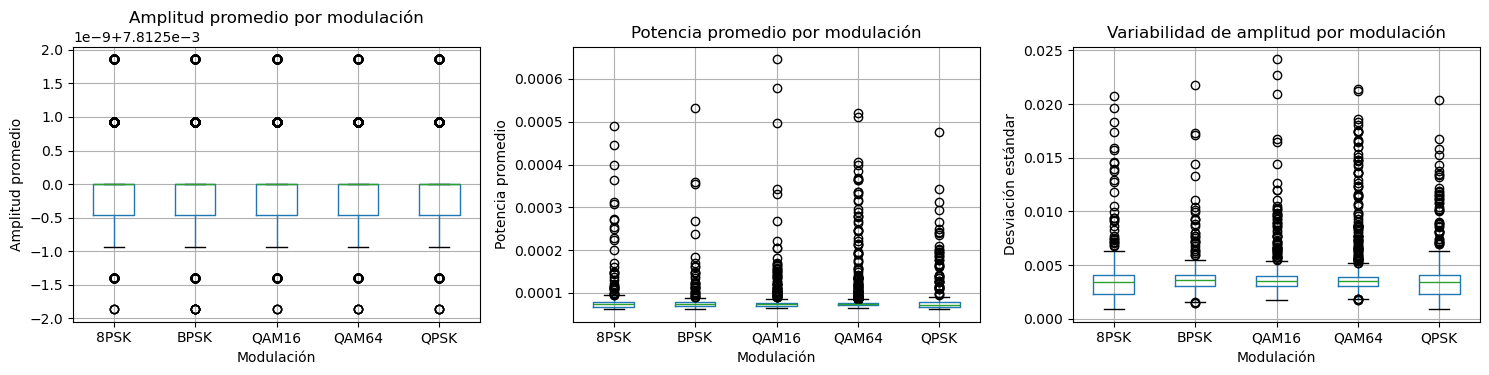

In [28]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_eda_features.boxplot(column="amplitude_mean", by="modulation", ax=axes[0])
axes[0].set_title("Amplitud promedio por modulación")
axes[0].set_xlabel("Modulación")
axes[0].set_ylabel("Amplitud promedio")

df_eda_features.boxplot(column="power_mean", by="modulation", ax=axes[1])
axes[1].set_title("Potencia promedio por modulación")
axes[1].set_xlabel("Modulación")
axes[1].set_ylabel("Potencia promedio")

df_eda_features.boxplot(column="amplitude_std", by="modulation", ax=axes[2])
axes[2].set_title("Variabilidad de amplitud por modulación")
axes[2].set_xlabel("Modulación")
axes[2].set_ylabel("Desviación estándar")

plt.suptitle("")
plt.tight_layout()
plt.show()

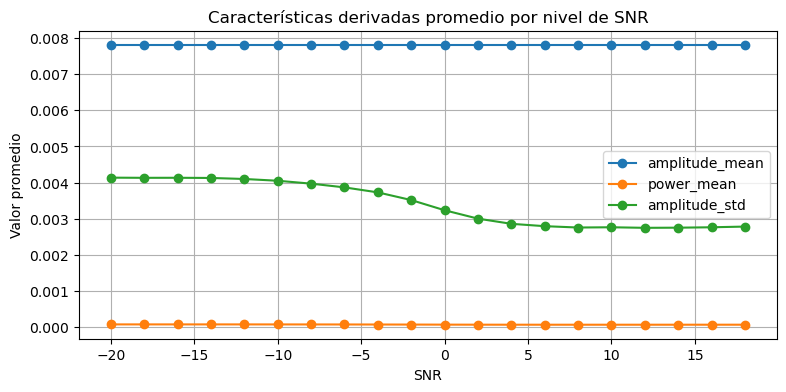

In [29]:
snr_feature_summary = df_eda_features.groupby("snr")[
    ["amplitude_mean", "power_mean", "amplitude_std"]
].mean()

snr_feature_summary.plot(figsize=(9, 4), marker="o")
plt.title("Características derivadas promedio por nivel de SNR")
plt.xlabel("SNR")
plt.ylabel("Valor promedio")
plt.grid(True)
plt.show()

El dataset seleccionado contiene 100 000 señales IQ correspondientes a cinco modulaciones digitales: BPSK, QPSK, 8PSK, QAM16 y QAM64. Cada señal tiene dos componentes, I y Q, con 128 muestras temporales, lo que produce 256 características al preparar los datos para una red neuronal MLP. El análisis mostró que el conjunto está balanceado por clase y por nivel de SNR, con 20 000 muestras por modulación y 5000 muestras por cada nivel de SNR.

Además, no se encontraron valores faltantes ni infinitos. Los valores IQ se encuentran normalizados alrededor de cero, con un rango aproximado entre -0.155 y 0.164. Las gráficas de señales IQ, amplitud, fase y potencia muestran que los datos corresponden a señales crudas y normalizadas, no a símbolos demodulados ideales. Por esta razón, las constelaciones no aparecen como puntos perfectos, sino como nubes, trayectorias o agrupaciones afectadas por transiciones, ruido y variaciones propias de la señal.

Finalmente, la potencia promedio calculada corresponde a una potencia normalizada en unidades arbitrarias, no a watts ni dBm. Las potencias promedio son similares entre modulaciones, lo que sugiere que la clasificación no puede basarse únicamente en la energía de la señal, sino que requiere aprender patrones más complejos de las componentes IQ.

## Feature Extraction

En esta versión se realiza Feature Extraction a partir de las señales IQ crudas. Aunque las componentes I y Q contienen la información original de la señal, se generan variables derivadas con significado físico, como amplitud, potencia y representación circular de la fase.

La amplitud se calcula como la magnitud de la señal compleja, la potencia como la energía instantánea normalizada, y la fase se representa mediante seno y coseno para evitar problemas de discontinuidad angular. Estas características se concatenan con las muestras IQ originales, con el objetivo de proporcionar al modelo MLP una representación más rica de la señal.

La extracción de características se realiza después de dividir el conjunto en entrenamiento y prueba, aplicando la misma función de transformación a ambos conjuntos.

In [30]:
def crear_features_iq(X_flat_input):
    """
    Crea características derivadas a partir de señales IQ aplanadas.

    Entrada:
        X_flat_input: matriz con forma (n_muestras, 256)
                      donde cada fila contiene I0...I127, Q0...Q127.

    Salida:
        X_features: matriz con IQ crudo + amplitud + potencia + fase circular + estadísticas.
    """

    X_iq = X_flat_input.reshape(X_flat_input.shape[0], 2, -1)

    I = X_iq[:, 0, :]
    Q = X_iq[:, 1, :]

    amplitude = np.sqrt(I**2 + Q**2)
    power = I**2 + Q**2

    phase = np.arctan2(Q, I)
    phase_sin = np.sin(phase)
    phase_cos = np.cos(phase)

    stats = np.column_stack([
        I.mean(axis=1),
        I.std(axis=1),
        Q.mean(axis=1),
        Q.std(axis=1),

        amplitude.mean(axis=1),
        amplitude.std(axis=1),
        amplitude.max(axis=1),
        amplitude.min(axis=1),

        power.mean(axis=1),
        power.std(axis=1),
        power.max(axis=1),
        power.min(axis=1),

        phase_sin.mean(axis=1),
        phase_sin.std(axis=1),
        phase_cos.mean(axis=1),
        phase_cos.std(axis=1)
    ])

    X_features = np.hstack([
        X_flat_input,
        amplitude,
        power,
        phase_sin,
        phase_cos,
        stats
    ])

    return X_features

## Preparación para modelado

Después del EDA, se prepara el conjunto de datos para ser utilizado por los modelos de machine learning. Como cada señal IQ tiene forma \(2 \times 128\), se aplana cada señal para obtener un vector de 256 características. Luego, las etiquetas de modulación se codifican numéricamente y se divide el dataset en conjuntos de entrenamiento y prueba.

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Aplanar señales IQ 
X_flat = X.reshape(X.shape[0], -1)

print("Forma original de X:", X.shape)
print("Forma aplanada de X:", X_flat.shape)

Forma original de X: (100000, 2, 128)
Forma aplanada de X: (100000, 256)


In [32]:
# Codificar etiquetas de modulación
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

print("Clases originales:", label_encoder.classes_)
print("Primeras etiquetas codificadas:", y_encoded[:10])

Clases originales: ['8PSK' 'BPSK' 'QAM16' 'QAM64' 'QPSK']
Primeras etiquetas codificadas: [4 4 4 4 4 4 4 4 4 4]


In [33]:
# Estratificación combinando modulación y SNR
stratify_key = np.array([f"{mod}_{snr}" for mod, snr in zip(y, snr_values)])

X_train, X_test, y_train, y_test, snr_train, snr_test = train_test_split(
    X_flat,
    y_encoded,
    snr_values,
    test_size=0.2,
    random_state=42,
    stratify=stratify_key
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)
print("snr_train:", snr_train.shape)
print("snr_test:", snr_test.shape)

X_train: (80000, 256)
X_test: (20000, 256)
y_train: (80000,)
y_test: (20000,)
snr_train: (80000,)
snr_test: (20000,)


In [34]:
# Guardar versión IQ cruda aplanada
X_train_raw = X_train.copy()
X_test_raw = X_test.copy()

# Crear versión mejorada con características derivadas
X_train = crear_features_iq(X_train_raw)
X_test = crear_features_iq(X_test_raw)

print("X_train crudo:", X_train_raw.shape)
print("X_test crudo:", X_test_raw.shape)

print("X_train con features:", X_train.shape)
print("X_test con features:", X_test.shape)

X_train crudo: (80000, 256)
X_test crudo: (20000, 256)
X_train con features: (80000, 784)
X_test con features: (20000, 784)


## Pipelines y Feature Selection

Se utilizan pipelines de  para integrar el preprocesamiento, la selección de características y el entrenamiento de los modelos en un único flujo de trabajo.

Cada pipeline incluye:

1. `StandardScaler`: estandariza las variables de entrada.
2. `SelectKBest`: aplica selección de características tipo filtro.
3. Modelo de clasificación: MLP o Regresión Logística L2.

La selección de características se realiza con `SelectKBest` y `f_classif`. Esta técnica evalúa la relación estadística entre cada característica y la clase objetivo, seleccionando las variables más relevantes. Al incluirla dentro del pipeline, se evita fuga de información, ya que la selección se ajusta únicamente con los datos de entrenamiento durante cada partición de validación cruzada.

In [35]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

## Pipeline MLP

##### Modelo principal: Red Neuronal MLP

El modelo principal es una red neuronal MLP. En esta versión, la MLP recibe una representación ampliada de cada señal IQ, compuesta por las muestras I/Q originales y características derivadas como amplitud, potencia y fase representada mediante seno y coseno. Esta representación busca proporcionar al modelo información física adicional de la señal.

In [36]:
pipeline_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("feature_selection", SelectKBest(score_func=f_classif, k=192)),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(256, 128),
        activation="relu",
        solver="adam",
        alpha=0.01,
        learning_rate_init=0.001,
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.20,
        n_iter_no_change=10,
        random_state=42
    ))
])

pipeline_mlp

,steps,"[('scaler', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,score_func,<function f_c...00215122D02C0>
,k,192
,hidden_layer_sizes,"(256, ...)"
,activation,'relu'


## Pipeline Regresión Logística L2

#### Modelo base: Regresión Logística con regularización L2

Como modelo base se utiliza Regresión Logística con regularización L2. Este modelo es un clasificador lineal regularizado y permite comparar si la MLP, al ser un modelo no lineal, logra mejorar el desempeño frente a una técnica más simple.

La regularización L2 penaliza pesos excesivamente grandes, ayudando a reducir el sobreajuste. En este modelo, el hiperparámetro principal es \(C\), que controla la fuerza de regularización. Valores pequeños de \(C\) implican mayor regularización, mientras que valores grandes reducen la penalización.

In [37]:
pipeline_logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("feature_selection", SelectKBest(score_func=f_classif, k=256)),
    ("logreg", LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="lbfgs",
        max_iter=1000
    ))
])

pipeline_logreg

,steps,"[('scaler', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,score_func,<function f_c...00215122D02C0>
,k,256
,penalty,'l2'
,dual,False


## Entrenamiento inicial de ambos modelos

#### Entrenamiento inicial de ambos modelos

Antes de optimizar hiperparámetros, se entrenan versiones iniciales de la MLP y de la Regresión Logística L2. Esto permite obtener una primera línea base de desempeño para comparar cómo se comportan ambos modelos sin ajuste fino.

In [38]:
def evaluar_modelo(modelo, X_test, y_test, nombre_modelo):
    y_pred = modelo.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    print(f"Accuracy {nombre_modelo}: {acc:.4f}")
    print()
    print(classification_report(
        y_test,
        y_pred,
        target_names=label_encoder.classes_
    ))
    
    cm = confusion_matrix(y_test, y_pred)
    
    fig, ax = plt.subplots(figsize=(7, 7))
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=label_encoder.classes_
    )
    disp.plot(ax=ax, values_format="d")
    plt.title(f"Matriz de confusión - {nombre_modelo}")
    plt.show()
    
    return y_pred, acc

Accuracy MLP inicial: 0.4392

              precision    recall  f1-score   support

        8PSK       0.34      0.37      0.35      4000
        BPSK       0.60      0.62      0.61      4000
       QAM16       0.38      0.31      0.34      4000
       QAM64       0.50      0.47      0.49      4000
        QPSK       0.38      0.42      0.40      4000

    accuracy                           0.44     20000
   macro avg       0.44      0.44      0.44     20000
weighted avg       0.44      0.44      0.44     20000



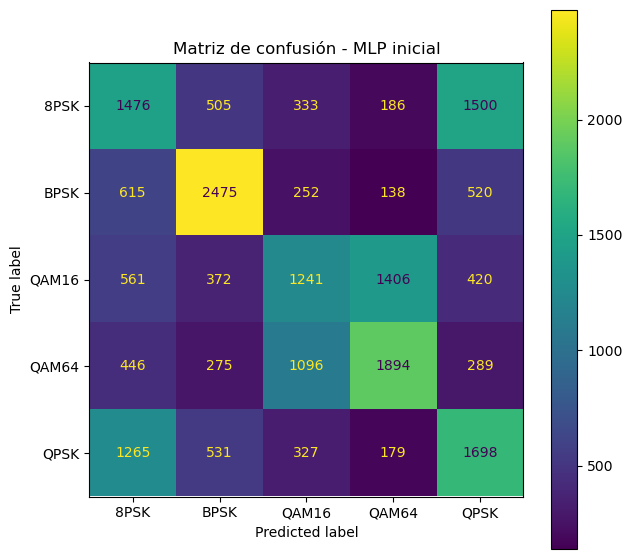

In [39]:
# Entrenamiento inicial MLP
pipeline_mlp.fit(X_train, y_train)

y_pred_mlp_initial, accuracy_mlp_initial = evaluar_modelo(
    pipeline_mlp,
    X_test,
    y_test,
    "MLP inicial"
)

Accuracy Regresión Logística L2 inicial: 0.3436

              precision    recall  f1-score   support

        8PSK       0.33      0.30      0.31      4000
        BPSK       0.48      0.45      0.47      4000
       QAM16       0.29      0.28      0.28      4000
       QAM64       0.29      0.33      0.31      4000
        QPSK       0.34      0.36      0.35      4000

    accuracy                           0.34     20000
   macro avg       0.35      0.34      0.34     20000
weighted avg       0.35      0.34      0.34     20000



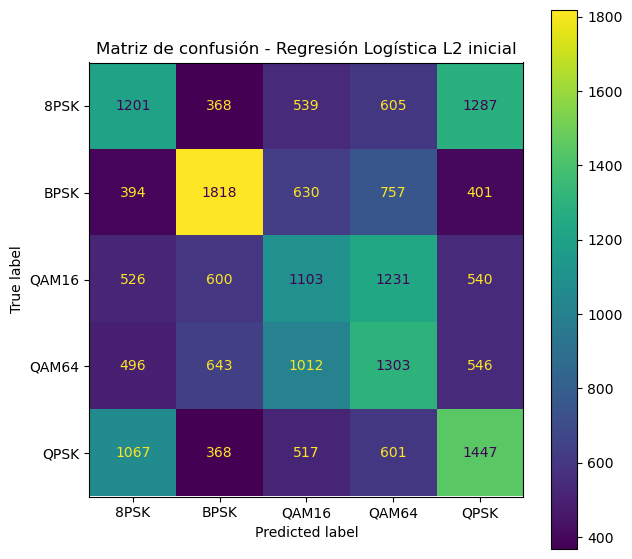

In [40]:
# Entrenamiento inicial Regresión Logística L2
pipeline_logreg.fit(X_train, y_train)

y_pred_logreg_initial, accuracy_logreg_initial = evaluar_modelo(
    pipeline_logreg,
    X_test,
    y_test,
    "Regresión Logística L2 inicial"
)

#### Optimización de hiperparámetros

La optimización de hiperparámetros se realiza mediante `GridSearchCV` con `RepeatedStratifiedKFold`. Debido al tamaño del dataset, se utiliza una muestra del conjunto de entrenamiento para reducir el costo computacional.

Se optimizan los hiperparámetros de la MLP y de la Regresión Logística L2. Esto permite realizar una comparación más justa entre ambos modelos, ya que no se compara un modelo optimizado contra otro sin optimizar.

En la MLP se optimizan:

- número de características seleccionadas por `SelectKBest`;
- arquitectura de capas ocultas;
- parámetro de regularización `alpha`;
- tasa de aprendizaje inicial.

En la Regresión Logística L2 se optimizan:

- número de características seleccionadas por `SelectKBest`;
- parámetro \(C\), asociado a la fuerza de regularización.

In [41]:
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold

# Muestra para optimización

OPT_SIZE = 40000

stratify_train_key = np.array([
    f"{label}_{snr}" for label, snr in zip(y_train, snr_train)
])

X_train_opt, _, y_train_opt, _, snr_train_opt, _ = train_test_split(
    X_train,
    y_train,
    snr_train,
    train_size=OPT_SIZE,
    random_state=42,
    stratify=stratify_train_key
)

print("X_train_opt:", X_train_opt.shape)
print("y_train_opt:", y_train_opt.shape)
print("snr_train_opt:", snr_train_opt.shape)

X_train_opt: (40000, 784)
y_train_opt: (40000,)
snr_train_opt: (40000,)


In [42]:
cv_opt = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=2,
    random_state=42
)

stratify_cv_key = np.array([
    f"{label}_{snr}" for label, snr in zip(y_train_opt, snr_train_opt)
])

cv_splits_opt = list(cv_opt.split(X_train_opt, stratify_cv_key))

print("Número de folds:", len(cv_splits_opt))

Número de folds: 10


## Optimizar MLP

In [43]:

param_grid_mlp = {
    "feature_selection__k": [128, 192, 256],

    "mlp__hidden_layer_sizes": [
        (128, 64),
        (256, 128)
    ],

    "mlp__alpha": [
        0.003,
        0.01,
        0.03
    ],

    "mlp__learning_rate_init": [
        0.001,
        0.0005
    ]
}


grid_search_mlp = GridSearchCV(
    estimator=pipeline_mlp,
    param_grid=param_grid_mlp,
    scoring="accuracy",
    cv=cv_splits_opt,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid_search_mlp.fit(X_train_opt, y_train_opt)

print("Mejores hiperparámetros MLP:")
print(grid_search_mlp.best_params_)

print("Mejor accuracy promedio en CV:")
print(grid_search_mlp.best_score_)



Fitting 10 folds for each of 36 candidates, totalling 360 fits
Mejores hiperparámetros MLP:
{'feature_selection__k': 256, 'mlp__alpha': 0.03, 'mlp__hidden_layer_sizes': (256, 128), 'mlp__learning_rate_init': 0.001}
Mejor accuracy promedio en CV:
0.404


## Optimizar Regresión Logística L2

In [44]:

import gc

gc.collect()

param_grid_logreg = {
    "feature_selection__k": [256, 384],
    "logreg__C": [0.01, 0.1, 1, 10]
}

grid_search_logreg = GridSearchCV(
    estimator=pipeline_logreg,
    param_grid=param_grid_logreg,
    scoring="accuracy",
    cv=cv_splits_opt,
    n_jobs=1,
    verbose=2,
    return_train_score=True,
    pre_dispatch=1
)

grid_search_logreg.fit(X_train_opt, y_train_opt)

print("Mejores hiperparámetros Regresión Logística L2:")
print(grid_search_logreg.best_params_)

print("Mejor accuracy promedio en CV:")
print(grid_search_logreg.best_score_)

Fitting 10 folds for each of 8 candidates, totalling 80 fits
[CV] END ...........feature_selection__k=256, logreg__C=0.01; total time=   3.3s
[CV] END ...........feature_selection__k=256, logreg__C=0.01; total time=   2.8s
[CV] END ...........feature_selection__k=256, logreg__C=0.01; total time=   3.0s
[CV] END ...........feature_selection__k=256, logreg__C=0.01; total time=   2.9s
[CV] END ...........feature_selection__k=256, logreg__C=0.01; total time=   2.5s
[CV] END ...........feature_selection__k=256, logreg__C=0.01; total time=   2.5s
[CV] END ...........feature_selection__k=256, logreg__C=0.01; total time=   2.3s
[CV] END ...........feature_selection__k=256, logreg__C=0.01; total time=   2.5s
[CV] END ...........feature_selection__k=256, logreg__C=0.01; total time=   2.7s
[CV] END ...........feature_selection__k=256, logreg__C=0.01; total time=   2.5s
[CV] END ............feature_selection__k=256, logreg__C=0.1; total time=   4.1s
[CV] END ............feature_selection__k=256, l

## Gráficas de optimización de hiperparámetros

Se grafica el error promedio de entrenamiento y validación cruzada frente a un hiperparámetro del modelo.

En la MLP se analiza el parámetro `alpha`, que corresponde a la regularización L2 interna del modelo. Valores muy bajos de regularización pueden favorecer sobreajuste, mientras que valores muy altos pueden generar subajuste.

En la Regresión Logística L2 se analiza el parámetro \(C\). Este parámetro es inverso a la fuerza de regularización: valores pequeños de \(C\) aplican mayor regularización, mientras que valores grandes aplican menor regularización.

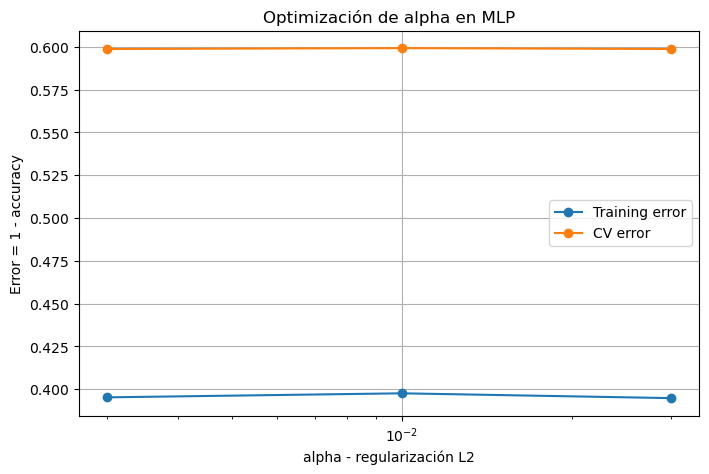

,param_mlp__alpha,mean_train_score,mean_test_score,train_error,cv_error
0,0.003,0.604804,0.401270,0.395196,0.598730
1,0.010,0.602445,0.400740,0.397555,0.599260
2,0.030,0.605259,0.401271,0.394741,0.598729


In [45]:
results_mlp = pd.DataFrame(grid_search_mlp.cv_results_)

# Agrupar resultados por alpha
mlp_alpha_curve = results_mlp.groupby("param_mlp__alpha").agg({
    "mean_train_score": "mean",
    "mean_test_score": "mean"
}).reset_index()

mlp_alpha_curve["train_error"] = 1 - mlp_alpha_curve["mean_train_score"]
mlp_alpha_curve["cv_error"] = 1 - mlp_alpha_curve["mean_test_score"]

plt.figure(figsize=(8, 5))
plt.plot(
    mlp_alpha_curve["param_mlp__alpha"],
    mlp_alpha_curve["train_error"],
    marker="o",
    label="Training error"
)
plt.plot(
    mlp_alpha_curve["param_mlp__alpha"],
    mlp_alpha_curve["cv_error"],
    marker="o",
    label="CV error"
)

plt.xscale("log")
plt.title("Optimización de alpha en MLP")
plt.xlabel("alpha - regularización L2")
plt.ylabel("Error = 1 - accuracy")
plt.legend()
plt.grid(True)
plt.show()

mlp_alpha_curve

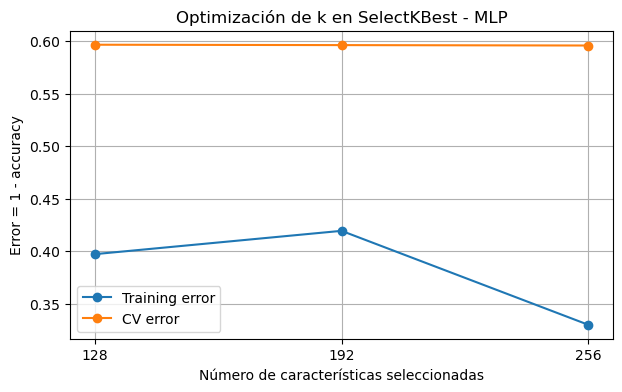

,param_feature_selection__k,mean_train_score,mean_test_score,train_error,cv_error
10,128,0.602641,0.403250,0.397359,0.596750
12,192,0.580456,0.403613,0.419544,0.596387
34,256,0.669847,0.404000,0.330153,0.596000


In [46]:
results_mlp["k_label"] = results_mlp["param_feature_selection__k"].astype(str)

idx_best_k = results_mlp.groupby("k_label")["mean_test_score"].idxmax()
best_by_k = results_mlp.loc[idx_best_k].copy()

best_by_k["cv_error"] = 1 - best_by_k["mean_test_score"]
best_by_k["train_error"] = 1 - best_by_k["mean_train_score"]

# Orden automático de k
def ordenar_k(valor):
    if valor == "all":
        return 999999
    return int(valor)

best_by_k["k_order"] = best_by_k["k_label"].apply(ordenar_k)
best_by_k = best_by_k.sort_values("k_order")

plt.figure(figsize=(7, 4))
plt.plot(
    best_by_k["k_label"].astype(str),
    best_by_k["train_error"],
    marker="o",
    label="Training error"
)
plt.plot(
    best_by_k["k_label"].astype(str),
    best_by_k["cv_error"],
    marker="o",
    label="CV error"
)

plt.title("Optimización de k en SelectKBest - MLP")
plt.xlabel("Número de características seleccionadas")
plt.ylabel("Error = 1 - accuracy")
plt.legend()
plt.grid(True)
plt.show()

best_by_k[[
    "param_feature_selection__k",
    "mean_train_score",
    "mean_test_score",
    "train_error",
    "cv_error"
]]

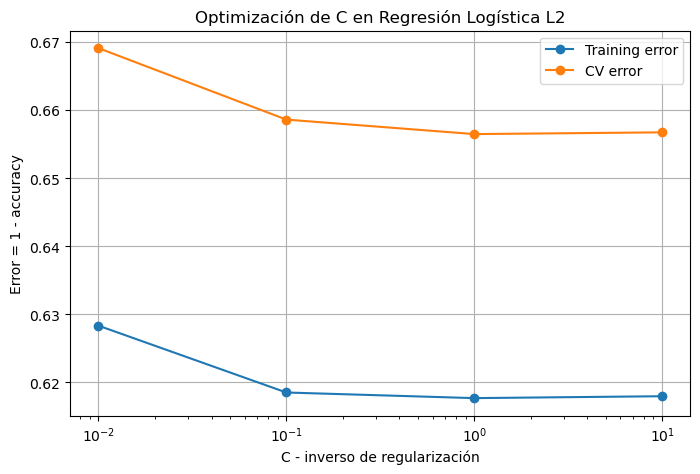

,param_logreg__C,mean_train_score,mean_test_score,train_error,cv_error
0,0.01,0.371661,0.330863,0.628339,0.669137
1,0.10,0.381486,0.341369,0.618514,0.658631
2,1.00,0.382312,0.343500,0.617687,0.656500
3,10.00,0.382033,0.343244,0.617967,0.656756


In [47]:
results_logreg = pd.DataFrame(grid_search_logreg.cv_results_)

# Agrupar resultados por C
logreg_c_curve = results_logreg.groupby("param_logreg__C").agg({
    "mean_train_score": "mean",
    "mean_test_score": "mean"
}).reset_index()

logreg_c_curve["train_error"] = 1 - logreg_c_curve["mean_train_score"]
logreg_c_curve["cv_error"] = 1 - logreg_c_curve["mean_test_score"]

plt.figure(figsize=(8, 5))
plt.plot(
    logreg_c_curve["param_logreg__C"],
    logreg_c_curve["train_error"],
    marker="o",
    label="Training error"
)
plt.plot(
    logreg_c_curve["param_logreg__C"],
    logreg_c_curve["cv_error"],
    marker="o",
    label="CV error"
)

plt.xscale("log")
plt.title("Optimización de C en Regresión Logística L2")
plt.xlabel("C - inverso de regularización")
plt.ylabel("Error = 1 - accuracy")
plt.legend()
plt.grid(True)
plt.show()

logreg_c_curve

## Entrenar mejores modelos

In [48]:
best_mlp = grid_search_mlp.best_estimator_
best_logreg = grid_search_logreg.best_estimator_

# Entrenar con todo el conjunto de entrenamiento
best_mlp.fit(X_train, y_train)
best_logreg.fit(X_train, y_train)

,steps,"[('scaler', ...), ('feature_selection', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,score_func,<function f_c...00215122D02C0>
,k,256
,penalty,'l2'
,dual,False


## Evaluar mejores modelos en test

#### Evaluación de los mejores modelos en test

Se evalúan los modelos optimizados sobre el conjunto de prueba. Esta evaluación permite estimar el desempeño final de cada modelo sobre datos que no fueron utilizados durante el entrenamiento ni durante la optimización.

Accuracy Mejor MLP con features IQ: 0.4316

              precision    recall  f1-score   support

        8PSK       0.37      0.39      0.38      4000
        BPSK       0.55      0.64      0.59      4000
       QAM16       0.39      0.26      0.31      4000
       QAM64       0.46      0.51      0.48      4000
        QPSK       0.36      0.36      0.36      4000

    accuracy                           0.43     20000
   macro avg       0.43      0.43      0.43     20000
weighted avg       0.43      0.43      0.43     20000



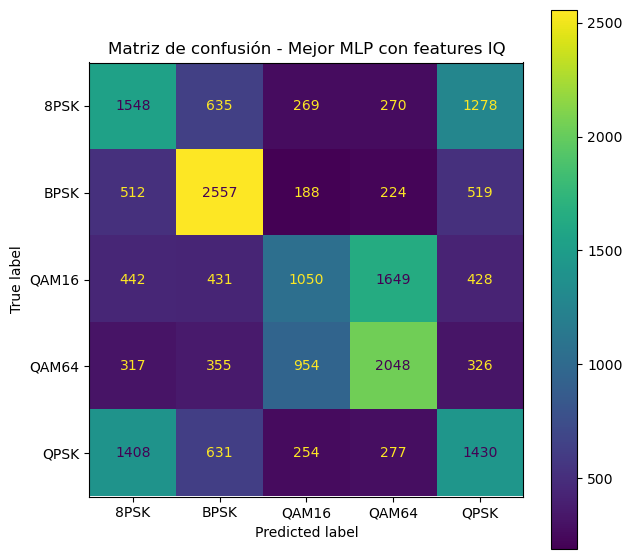

In [49]:
y_pred_best_mlp, accuracy_best_mlp = evaluar_modelo(
    best_mlp,
    X_test,
    y_test,
    "Mejor MLP con features IQ"
)

Accuracy Mejor Regresión Logística L2 con features IQ: 0.3436

              precision    recall  f1-score   support

        8PSK       0.33      0.30      0.31      4000
        BPSK       0.48      0.45      0.47      4000
       QAM16       0.29      0.28      0.28      4000
       QAM64       0.29      0.33      0.31      4000
        QPSK       0.34      0.36      0.35      4000

    accuracy                           0.34     20000
   macro avg       0.35      0.34      0.34     20000
weighted avg       0.35      0.34      0.34     20000



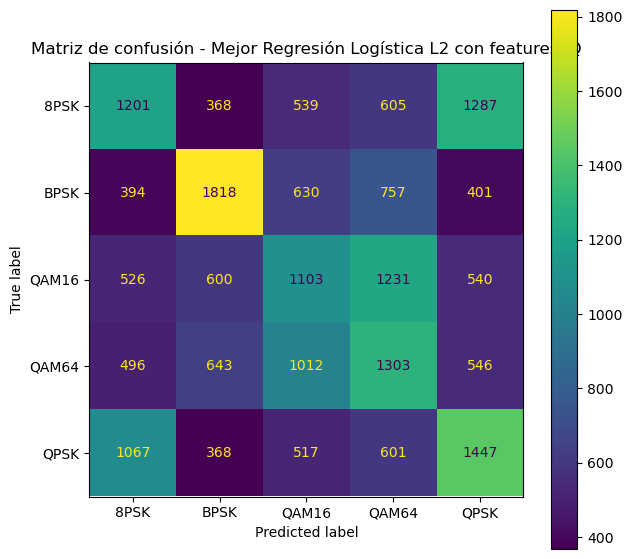

In [50]:
y_pred_best_logreg, accuracy_best_logreg = evaluar_modelo(
    best_logreg,
    X_test,
    y_test,
    "Mejor Regresión Logística L2 con features IQ"
)

In [51]:
accuracy_mlp_segura = 0.3454

print("Resumen de accuracies:")
print("MLP segura con IQ crudo:", accuracy_mlp_segura)
print("MLP mejorada con features IQ:", accuracy_best_mlp)
print("Regresión Logística L2 mejorada:", accuracy_best_logreg)

Resumen de accuracies:
MLP segura con IQ crudo: 0.3454
MLP mejorada con features IQ: 0.43165
Regresión Logística L2 mejorada: 0.3436


## Evaluación por SNR

#### Evaluación por nivel de SNR

Como el dataset contiene señales con diferentes niveles de SNR, se analiza el accuracy del mejor modelo MLP según el nivel de ruido. Esto permite evaluar si el modelo clasifica mejor cuando la señal tiene menos ruido y si presenta dificultades cuando el SNR es bajo.

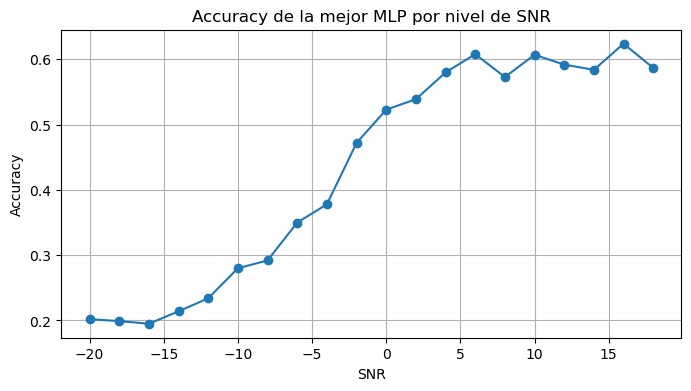

snr
-20    0.202
-18    0.199
-16    0.195
-14    0.214
-12    0.234
-10    0.280
-8     0.292
-6     0.350
-4     0.378
-2     0.472
 0     0.523
 2     0.539
 4     0.580
 6     0.608
 8     0.573
 10    0.607
 12    0.592
 14    0.584
 16    0.624
 18    0.587
Name: correct, dtype: float64

In [52]:
df_eval_snr = pd.DataFrame({
    "y_true": label_encoder.inverse_transform(y_test),
    "y_pred": label_encoder.inverse_transform(y_pred_best_mlp),
    "snr": snr_test
})

df_eval_snr["correct"] = df_eval_snr["y_true"] == df_eval_snr["y_pred"]

accuracy_by_snr = df_eval_snr.groupby("snr")["correct"].mean()

plt.figure(figsize=(8, 4))
plt.plot(accuracy_by_snr.index, accuracy_by_snr.values, marker="o")
plt.title("Accuracy de la mejor MLP por nivel de SNR")
plt.xlabel("SNR")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

accuracy_by_snr

## Comparación estadística entre dos técnicas ML

#### Comparación estadística entre MLP y Regresión Logística L2

Se realiza una comparación estadística entre los dos modelos optimizados: MLP y Regresión Logística L2. Para ello se utiliza repeated k-fold cross-validation, obteniendo múltiples valores de accuracy para cada modelo.

Posteriormente, se aplica la prueba de Wilcoxon para evaluar si existe una diferencia estadísticamente significativa entre los desempeños de ambos modelos.

La hipótesis nula establece que no existe diferencia significativa entre los modelos. Si el valor p es menor que 0.05, se rechaza la hipótesis nula y se concluye que existe evidencia estadística de diferencia entre ambos clasificadores.

In [53]:
from sklearn.model_selection import cross_val_score
from scipy.stats import wilcoxon

COMPARE_SIZE = 40000

stratify_compare_key = np.array([
    f"{label}_{snr}" for label, snr in zip(y_train, snr_train)
])

X_compare, _, y_compare, _, snr_compare, _ = train_test_split(
    X_train,
    y_train,
    snr_train,
    train_size=COMPARE_SIZE,
    random_state=42,
    stratify=stratify_compare_key
)

cv_compare = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=2,
    random_state=42
)

stratify_compare_cv_key = np.array([
    f"{label}_{snr}" for label, snr in zip(y_compare, snr_compare)
])

cv_splits_compare = list(cv_compare.split(X_compare, stratify_compare_cv_key))

mlp_scores = cross_val_score(
    best_mlp,
    X_compare,
    y_compare,
    cv=cv_splits_compare,
    scoring="accuracy",
    n_jobs=-1
)

logreg_scores = cross_val_score(
    best_logreg,
    X_compare,
    y_compare,
    cv=cv_splits_compare,
    scoring="accuracy",
    n_jobs=-1
)

print("Scores MLP:", mlp_scores)
print("Scores Regresión Logística L2:", logreg_scores)

print("Media MLP:", np.mean(mlp_scores))
print("Desviación estándar MLP:", np.std(mlp_scores))

print("Media Regresión Logística L2:", np.mean(logreg_scores))
print("Desviación estándar Regresión Logística L2:", np.std(logreg_scores))

stat, p_value = wilcoxon(mlp_scores, logreg_scores)

print("Estadístico Wilcoxon:", stat)
print("p-value:", p_value)

Scores MLP: [0.404125 0.41225  0.41125  0.395625 0.412125 0.39775  0.410125 0.4045
 0.394625 0.397625]
Scores Regresión Logística L2: [0.3455   0.349625 0.333    0.341625 0.345125 0.34225  0.34675  0.34325
 0.340875 0.35375 ]
Media MLP: 0.404
Desviación estándar MLP: 0.006798207484329973
Media Regresión Logística L2: 0.344175
Desviación estándar Regresión Logística L2: 0.005267886198467085
Estadístico Wilcoxon: 0.0
p-value: 0.001953125


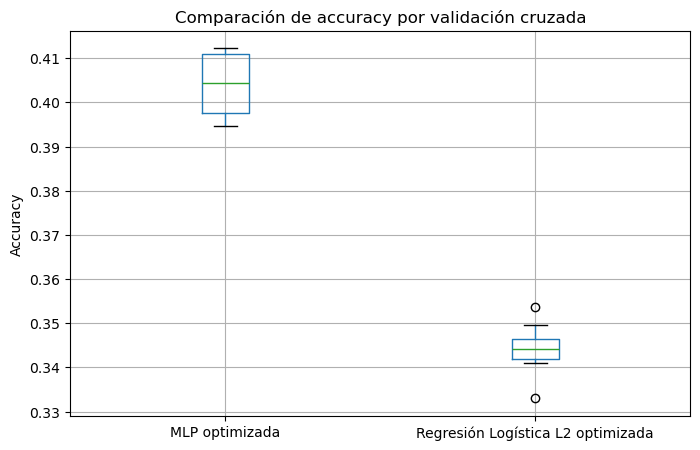

In [54]:
comparison_df = pd.DataFrame({
    "MLP optimizada": mlp_scores,
    "Regresión Logística L2 optimizada": logreg_scores
})

comparison_df.boxplot(figsize=(8, 5))
plt.title("Comparación de accuracy por validación cruzada")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

## Curva de aprendizaje

La curva de aprendizaje permite analizar el comportamiento del modelo al aumentar el tamaño del conjunto de entrenamiento. Se comparan el error de entrenamiento y el error de validación.

Si el error de entrenamiento es bajo y el error de validación es alto, puede existir sobreajuste. Si ambos errores son altos, puede existir subajuste. Si el error de validación disminuye al aumentar los datos, el modelo se beneficia de una mayor cantidad de muestras.

In [55]:
from sklearn.model_selection import learning_curve, RepeatedStratifiedKFold

LC_SIZE = 40000

# Crear clave de estratificación combinando clase y SNR
stratify_lc_key = np.array([
    f"{label}_{snr}" for label, snr in zip(y_train, snr_train)
])

X_lc, _, y_lc, _, snr_lc, _ = train_test_split(
    X_train,
    y_train,
    snr_train,
    train_size=LC_SIZE,
    random_state=42,
    stratify=stratify_lc_key
)

print("X_lc:", X_lc.shape)
print("y_lc:", y_lc.shape)
print("snr_lc:", snr_lc.shape)

X_lc: (40000, 784)
y_lc: (40000,)
snr_lc: (40000,)


In [56]:
cv_lc = RepeatedStratifiedKFold(
    n_splits=3,
    n_repeats=1,
    random_state=42
)

stratify_lc_cv_key = np.array([
    f"{label}_{snr}" for label, snr in zip(y_lc, snr_lc)
])

cv_splits_lc = list(
    cv_lc.split(X_lc, stratify_lc_cv_key)
)

print("Número de folds para learning curve:", len(cv_splits_lc))

Número de folds para learning curve: 3


In [57]:
train_sizes, train_scores, val_scores = learning_curve(
    best_mlp,
    X_lc,
    y_lc,
    cv=cv_splits_lc,
    scoring="accuracy",
    train_sizes=[0.1, 0.3, 0.5, 0.7, 1.0],
    n_jobs=-1
)

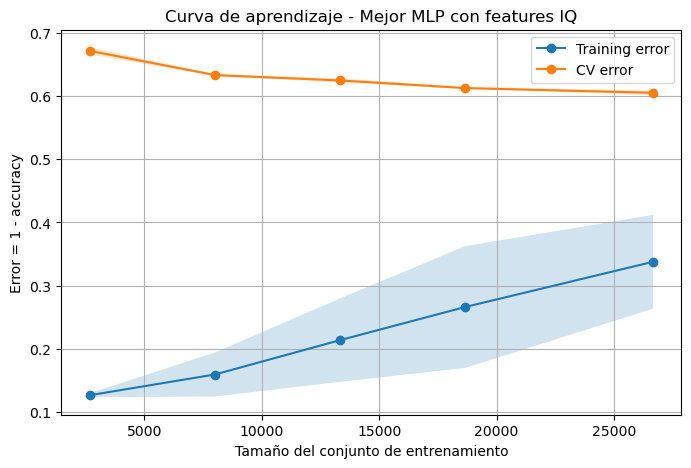

In [58]:
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)

val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

train_error = 1 - train_mean
val_error = 1 - val_mean

plt.figure(figsize=(8, 5))

plt.plot(
    train_sizes,
    train_error,
    marker="o",
    label="Training error"
)

plt.plot(
    train_sizes,
    val_error,
    marker="o",
    label="CV error"
)

plt.fill_between(
    train_sizes,
    train_error - train_std,
    train_error + train_std,
    alpha=0.2
)

plt.fill_between(
    train_sizes,
    val_error - val_std,
    val_error + val_std,
    alpha=0.2
)

plt.title("Curva de aprendizaje - Mejor MLP con features IQ")
plt.xlabel("Tamaño del conjunto de entrenamiento")
plt.ylabel("Error = 1 - accuracy")
plt.legend()
plt.grid(True)
plt.show()

## Visualización con t-SNE

Se utiliza t-SNE para proyectar el espacio de características a dos dimensiones. Cada punto representa una señal IQ y el color representa la modulación real. Esta visualización permite observar si las clases forman agrupamientos o si existe superposición entre modulaciones.

Debido al costo computacional de t-SNE, se utiliza una muestra del conjunto de prueba.

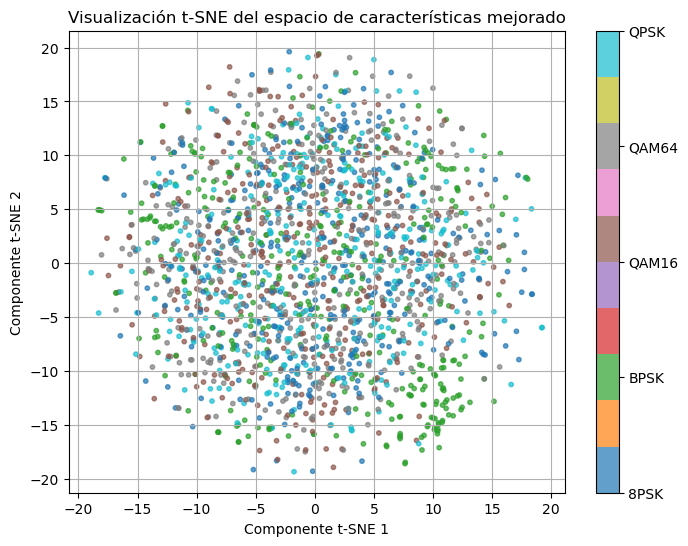

In [59]:
from sklearn.manifold import TSNE

np.random.seed(42)

sample_size = 2000

idx = np.random.choice(
    np.arange(X_test.shape[0]),
    size=sample_size,
    replace=False
)

X_sample = X_test[idx]
y_sample = y_test[idx]

# Aplicar el preprocesamiento del mejor pipeline: scaler + feature_selection
X_sample_processed = best_mlp[:-1].transform(X_sample)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

X_tsne = tsne.fit_transform(X_sample_processed)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_tsne[:, 0],
    X_tsne[:, 1],
    c=y_sample,
    cmap="tab10",
    s=10,
    alpha=0.7
)

plt.title("Visualización t-SNE del espacio de características mejorado")
plt.xlabel("Componente t-SNE 1")
plt.ylabel("Componente t-SNE 2")

cbar = plt.colorbar(scatter)
cbar.set_ticks(range(len(label_encoder.classes_)))
cbar.set_ticklabels(label_encoder.classes_)

plt.grid(True)
plt.show()